# Plot IGT choice variability and Q-value error metrics

In [20]:

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

metrics_dir = os.path.join(
    project_root,
    "results",
    "decision_making_tasks",
    "data",
    "igt",
)

lat_arr = [0.0275, 0.0325, 0.0375, 0.0425, 0.0475]
normal_file = os.path.join(metrics_dir, "igt_choice_q_metrics_normal.pkl")


Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making


In [21]:

def load_pkl(path):
    with open(path, "rb") as f:
        return pickle.load(f)


def to_float(x):
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    return float(np.asarray(x))


def get_condition_key(type_list, possible_names):
    for name in possible_names:
        for t in type_list:
            if str(t).lower() == name.lower():
                return t

    for name in possible_names:
        for t in type_list:
            if name.lower() in str(t).lower():
                return t

    raise KeyError(f"Could not find condition from {possible_names}. Available TYPE = {type_list}")


def get_delta_key(monitor, condition_key, d):
    if d in monitor[condition_key]:
        return d
    if float(d) in monitor[condition_key]:
        return float(d)

    available_keys = list(monitor[condition_key].keys())
    available_float = np.array(available_keys, dtype=float)
    return available_keys[np.argmin(np.abs(available_float - float(d)))]


def get_metric_array(monitor, condition_key, delta_vals, metric_key):
    vals = []
    for d in delta_vals:
        d_key = get_delta_key(monitor, condition_key, d)
        vals.append(to_float(monitor[condition_key][d_key][metric_key]))
    return np.array(vals)


In [22]:

# Load normal values
normal_data = load_pkl(normal_file)

normal_values = {
    "mean_entropy": normal_data["entropy"],
    "mean_switching": normal_data["switching"],
    "mean_combined_variability": normal_data["entropy_plus_switching"],
    "mean_q_rmse": normal_data["q_error"],
}

print("Normal values")
print("-------------")
print(f"Entropy             = {normal_values['mean_entropy']:.4f}")
print(f"Switching           = {normal_values['mean_switching']:.4f}")
print(f"Entropy + switching = {normal_values['mean_combined_variability']:.4f}")
print(f"Q-value error       = {normal_values['mean_q_rmse']:.4f}")


Normal values
-------------
Entropy             = 0.2512
Switching           = 0.1293
Entropy + switching = 0.2146
Q-value error       = 0.3750


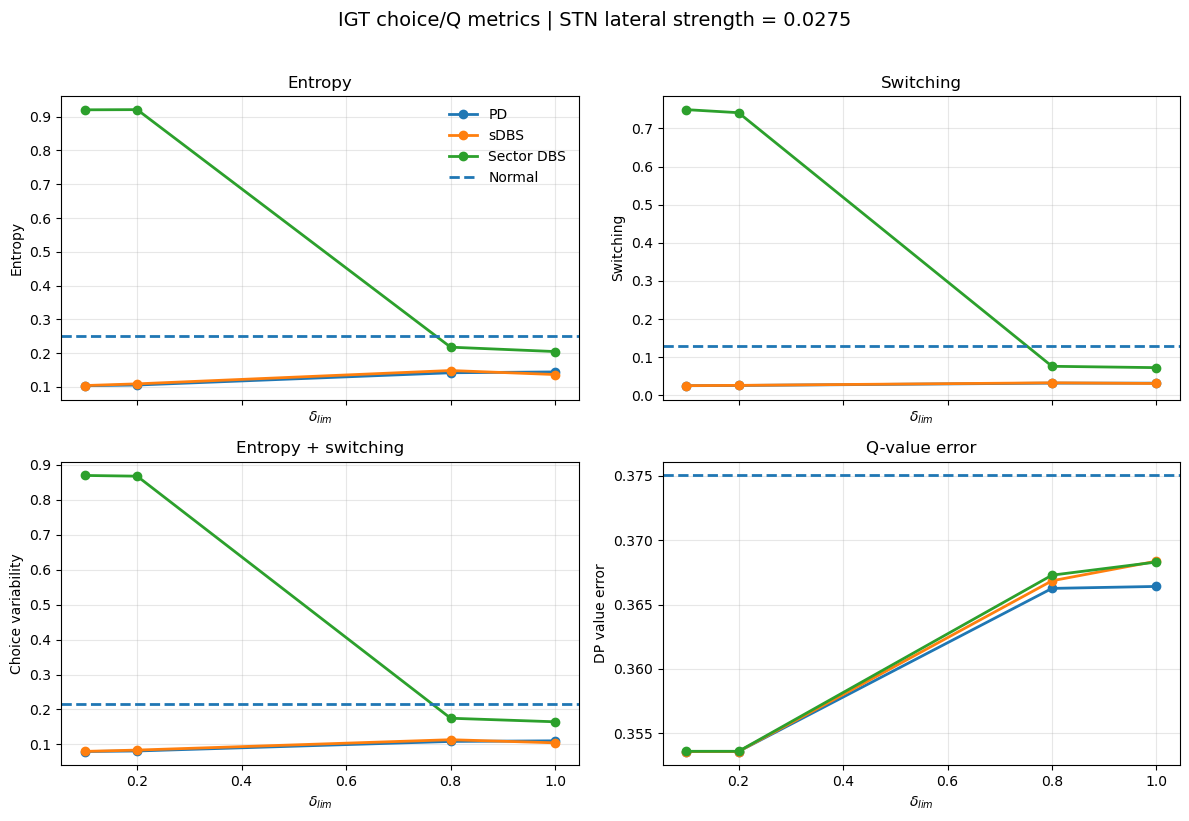

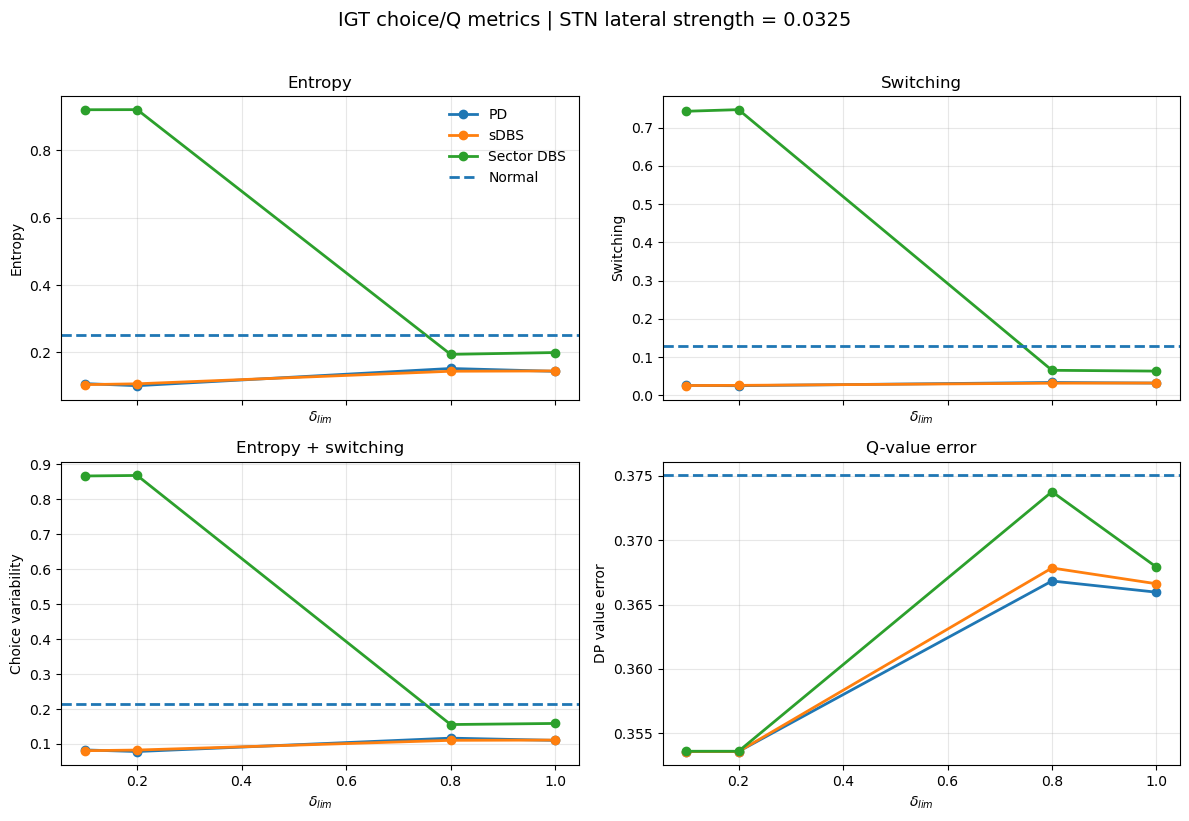

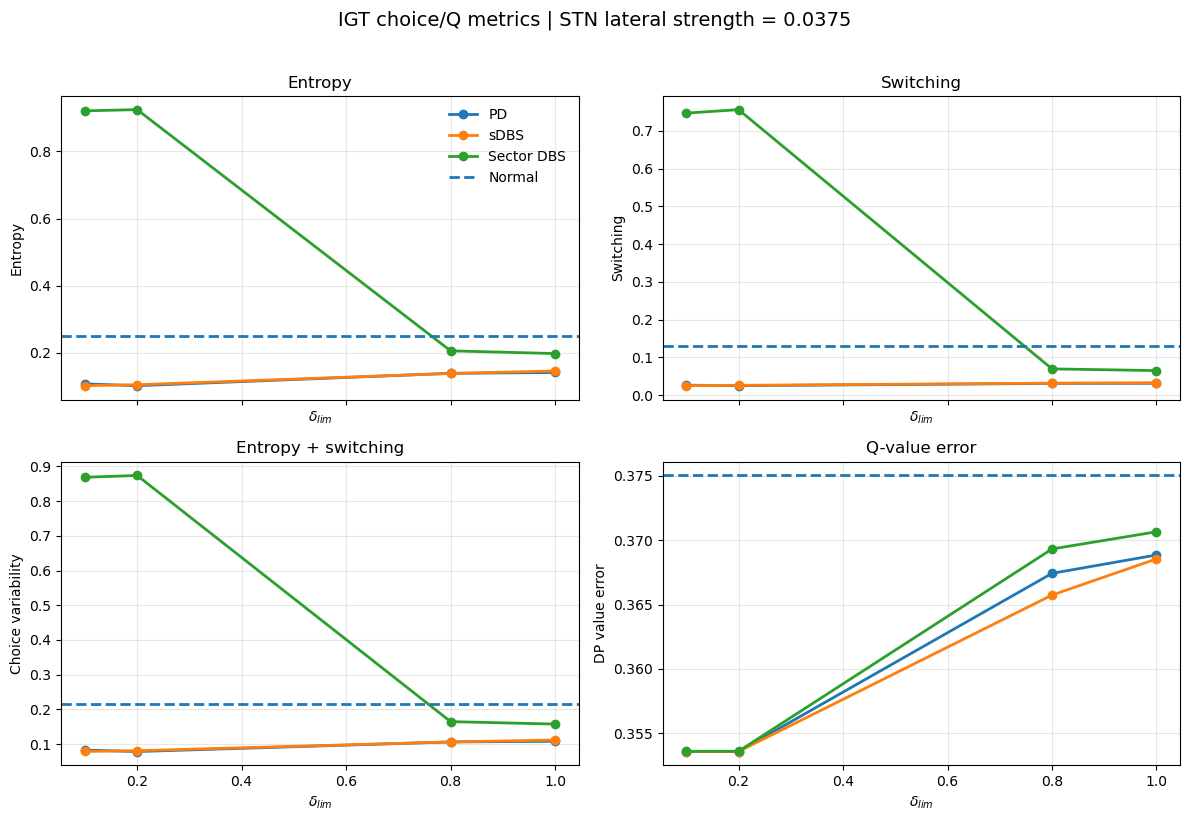

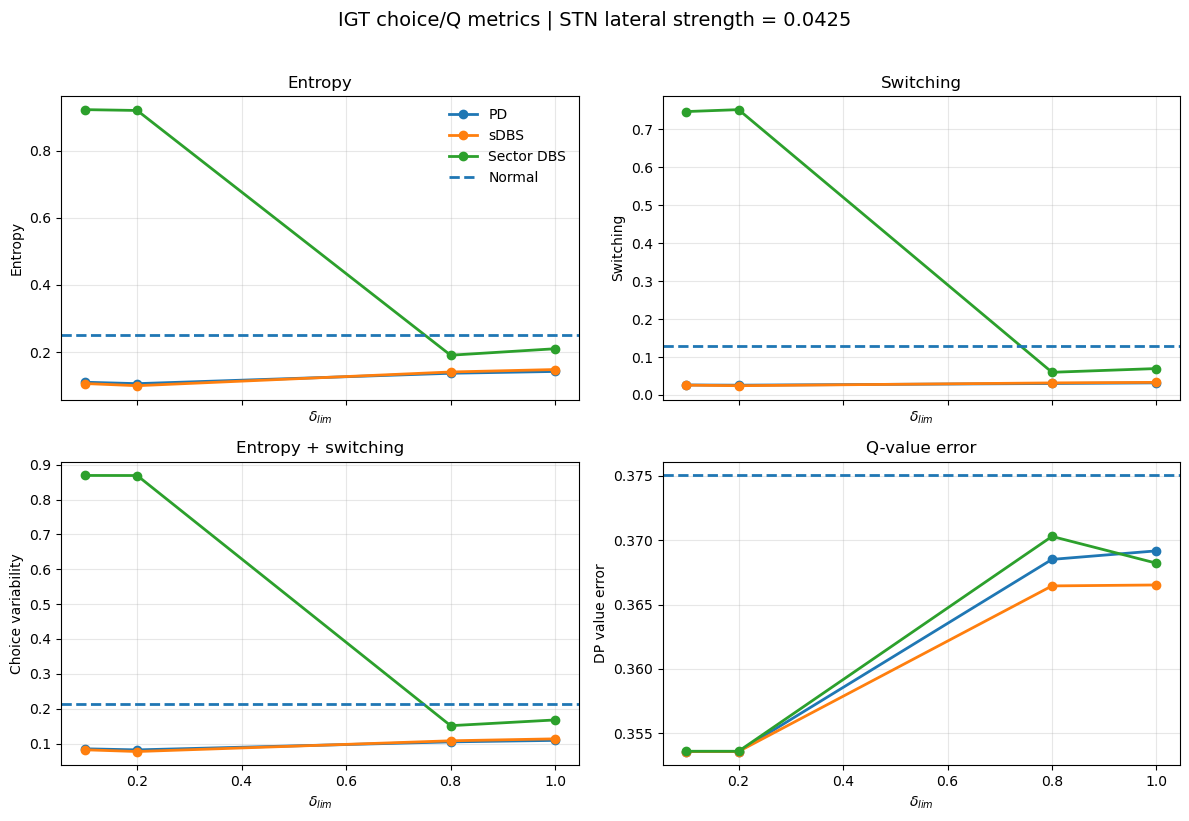

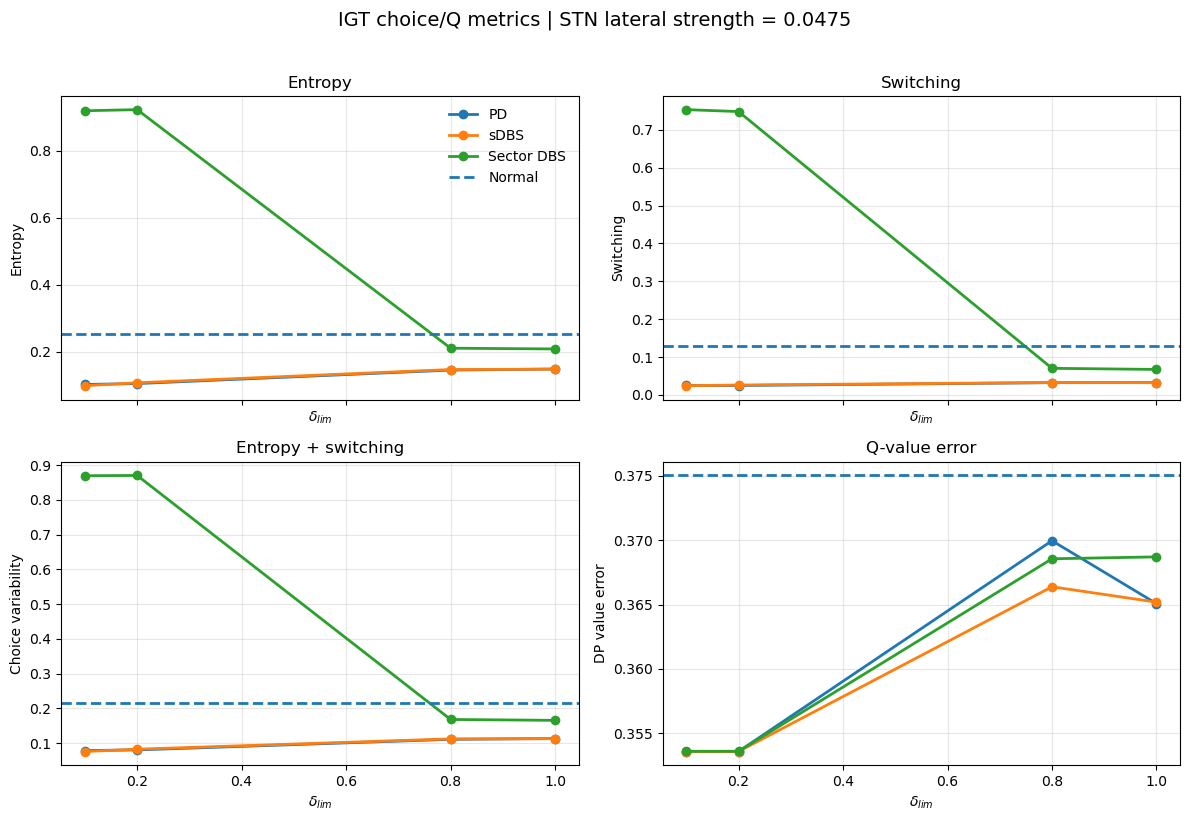

In [23]:

metric_specs = [
    {
        "title": "Entropy",
        "monitor_name": "CHOICE_VARIABILITY_METRICS_MONITOR",
        "metric_key": "mean_entropy",
        "ylabel": "Entropy",
    },
    {
        "title": "Switching",
        "monitor_name": "CHOICE_VARIABILITY_METRICS_MONITOR",
        "metric_key": "mean_switching",
        "ylabel": "Switching",
    },
    {
        "title": "Entropy + switching",
        "monitor_name": "CHOICE_VARIABILITY_METRICS_MONITOR",
        "metric_key": "mean_combined_variability",
        "ylabel": "Choice variability",
    },
    {
        "title": "Q-value error",
        "monitor_name": "Q_ERROR_METRICS_MONITOR",
        "metric_key": "mean_q_rmse",
        "ylabel": "DP value error",
    },
]

for lat_strength in lat_arr:
    lat_str = str(lat_strength).replace(".", "_")
    metrics_file = os.path.join(metrics_dir, f"igt_choice_q_metrics_lat_{lat_str}.pkl")

    if not os.path.exists(metrics_file):
        print(f"Skipping missing file: {metrics_file}")
        continue

    data = load_pkl(metrics_file)

    delta_vals = data["DEL_LIM_ARR"]
    type_list = data["TYPE"]

    pd_key = get_condition_key(type_list, ["PD"])
    dbs_key = get_condition_key(type_list, ["STD_DBS", "DBS", "sDBS", "PD-sDBS"])
    sector_key = get_condition_key(type_list, ["SECTOR_DBS", "sector DBS", "rDBS", "PD-rDBS"])

    condition_keys = [pd_key, dbs_key, sector_key]
    condition_labels = ["PD", "sDBS", "Sector DBS"]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.ravel()

    for ax, spec in zip(axes, metric_specs):
        monitor = data[spec["monitor_name"]]

        for cond_key, cond_label in zip(condition_keys, condition_labels):
            vals = get_metric_array(
                monitor=monitor,
                condition_key=cond_key,
                delta_vals=delta_vals,
                metric_key=spec["metric_key"],
            )

            ax.plot(
                delta_vals,
                vals,
                marker="o",
                linewidth=2,
                markersize=6,
                label=cond_label,
            )

        ax.axhline(
            normal_values[spec["metric_key"]],
            linestyle="--",
            linewidth=2,
            label="Normal" if spec["title"] == "Entropy" else None,
        )

        ax.set_title(spec["title"])
        ax.set_xlabel(r"$\delta_{lim}$")
        ax.set_ylabel(spec["ylabel"])
        ax.grid(True, alpha=0.3)

    axes[0].legend(frameon=False)

    plt.suptitle(
        f"IGT choice/Q metrics | STN lateral strength = {lat_strength}",
        fontsize=14,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


In [24]:

# Print all values in one table
rows = []

# normal row
rows.append({
    "lat_strength": "normal",
    "condition": "Normal",
    "delta_lim": "no_limit",
    "entropy": normal_values["mean_entropy"],
    "switching": normal_values["mean_switching"],
    "entropy_plus_switching": normal_values["mean_combined_variability"],
    "q_error": normal_values["mean_q_rmse"],
})

for lat_strength in lat_arr:
    lat_str = str(lat_strength).replace(".", "_")
    metrics_file = os.path.join(metrics_dir, f"igt_choice_q_metrics_lat_{lat_str}.pkl")

    if not os.path.exists(metrics_file):
        continue

    data = load_pkl(metrics_file)
    delta_vals = data["DEL_LIM_ARR"]
    type_list = data["TYPE"]

    pd_key = get_condition_key(type_list, ["PD"])
    dbs_key = get_condition_key(type_list, ["STD_DBS", "DBS", "sDBS", "PD-sDBS"])
    sector_key = get_condition_key(type_list, ["SECTOR_DBS", "sector DBS", "rDBS", "PD-rDBS"])

    condition_keys = [pd_key, dbs_key, sector_key]
    condition_labels = ["PD", "sDBS", "Sector DBS"]

    for cond_key, cond_label in zip(condition_keys, condition_labels):
        for d in delta_vals:
            d_choice = get_delta_key(data["CHOICE_VARIABILITY_METRICS_MONITOR"], cond_key, d)
            d_q = get_delta_key(data["Q_ERROR_METRICS_MONITOR"], cond_key, d)

            choice_metrics = data["CHOICE_VARIABILITY_METRICS_MONITOR"][cond_key][d_choice]
            q_metrics = data["Q_ERROR_METRICS_MONITOR"][cond_key][d_q]

            rows.append({
                "lat_strength": lat_strength,
                "condition": cond_label,
                "delta_lim": d,
                "entropy": choice_metrics["mean_entropy"],
                "switching": choice_metrics["mean_switching"],
                "entropy_plus_switching": choice_metrics["mean_combined_variability"],
                "q_error": q_metrics["mean_q_rmse"],
            })

metrics_table = pd.DataFrame(rows)
metrics_table


,lat_strength,condition,delta_lim,entropy,switching,entropy_plus_switching,q_error
0,normal,Normal,no_limit,0.251155,0.129319,0.214604,0.375040
1,0.0275,PD,0.1,0.103234,0.025199,0.079824,0.353565
2,0.0275,PD,0.2,0.105228,0.025772,0.081391,0.353566
3,0.0275,PD,0.8,0.141551,0.031985,0.108681,0.366255
4,0.0275,PD,1.0,0.144061,0.031836,0.110393,0.366407
...,...,...,...,...,...,...,...
56,0.0475,sDBS,1.0,0.147557,0.032425,0.113017,0.365184
57,0.0475,Sector DBS,0.1,0.919650,0.753463,0.869794,0.353584
58,0.0475,Sector DBS,0.2,0.922967,0.748380,0.870591,0.353585
59,0.0475,Sector DBS,0.8,0.210246,0.070407,0.168294,0.368558


In [25]:
display(metrics_table)

,lat_strength,condition,delta_lim,entropy,switching,entropy_plus_switching,q_error
0,normal,Normal,no_limit,0.251155,0.129319,0.214604,0.375040
1,0.0275,PD,0.1,0.103234,0.025199,0.079824,0.353565
2,0.0275,PD,0.2,0.105228,0.025772,0.081391,0.353566
3,0.0275,PD,0.8,0.141551,0.031985,0.108681,0.366255
4,0.0275,PD,1.0,0.144061,0.031836,0.110393,0.366407
...,...,...,...,...,...,...,...
56,0.0475,sDBS,1.0,0.147557,0.032425,0.113017,0.365184
57,0.0475,Sector DBS,0.1,0.919650,0.753463,0.869794,0.353584
58,0.0475,Sector DBS,0.2,0.922967,0.748380,0.870591,0.353585
59,0.0475,Sector DBS,0.8,0.210246,0.070407,0.168294,0.368558


In [26]:
with pd.option_context(
    'display.max_rows', None,
    'display.max_columns', None,
    'display.max_colwidth', None
):
    display(metrics_table)

,lat_strength,condition,delta_lim,entropy,switching,entropy_plus_switching,q_error
0,normal,Normal,no_limit,0.251155,0.129319,0.214604,0.375040
1,0.0275,PD,0.1,0.103234,0.025199,0.079824,0.353565
2,0.0275,PD,0.2,0.105228,0.025772,0.081391,0.353566
3,0.0275,PD,0.8,0.141551,0.031985,0.108681,0.366255
4,0.0275,PD,1.0,0.144061,0.031836,0.110393,0.366407
5,0.0275,sDBS,0.1,0.103692,0.025357,0.080191,0.353565
6,0.0275,sDBS,0.2,0.108708,0.026096,0.083925,0.353566
7,0.0275,sDBS,0.8,0.148199,0.032782,0.113574,0.366848
8,0.0275,sDBS,1.0,0.136288,0.030997,0.104700,0.368374
9,0.0275,Sector DBS,0.1,0.920477,0.749435,0.869164,0.353582
